# Common Libraries

In [28]:
import os, sys, shutil, functools
import numpy as np
from typing import List, Dict, Tuple
from copy import deepcopy
import matplotlib.pylab as plt

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"

# Mujoco
import mujoco

# GPU setting
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

# Jax
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "true"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".60" 

import jax
jax.config.update("jax_enable_x64", True)
from jax import numpy as jnp
from jaxtyping import Integer, Float, Array

# Mujoco jax
from mujoco import mjx
from mujoco.mjx._src.types import TrnType

# Custom Libraries

In [29]:
sys.path.append("/home/seojin/Seojin_commonTool/Module")
from vis_3D import Plotter3D
from sj_datastructure import make_3d_dataset
from jupyter_util import is_jupyter

# Params

In [30]:
if is_jupyter():
    model_path = "/home/seojin/biomechanics_tools/MonocularBiomechanics/monocular_demos/biomechanics_mjx/data/humanoid/humanoid_torque.xml"
    # model_path = "/mnt/sdb2/DeepProprioception/MyoSuite/muscle_mimic/muscle_mimic.xml"
    scale = 2
    save_path = "/mnt/ext1/seojin/temp/scale/scaled_param.npz"
    is_plot = True
else:
    model_path = sys.argv[1]
    scale = int(sys.argv[2])
    save_path = sys.argv[3]
    is_plot = bool(sys.argv[4])

# Initialize model

In [31]:
# Mujoco model
origin_model = mujoco.MjModel.from_xml_path(model_path)
body_names = [origin_model.body(i).name for i in range(len(origin_model.body_pos))]

# Jax model
mjx_model = mjx.put_model(origin_model)

# Tendon info
muscle_actuated = mjx_model.actuator_trntype == TrnType.TENDON
tendon_ids = mjx_model.actuator_trnid[muscle_actuated, 0]
tendon_names = [mujoco.mj_id2name(origin_model, mujoco.mjtObj.mjOBJ_TENDON, int(t_id)) for t_id in tendon_ids]

# Constants

In [32]:
scales = jnp.ones((origin_model.nbody, 1)) * scale

n_bodies = origin_model.nbody
n_sites = origin_model.nsite
n_geoms = origin_model.ngeom
n_vertices = origin_model.nmeshvert

# Plotter

In [33]:
plotter = Plotter3D()

# Body

In [34]:
body_mixer = jnp.zeros((n_bodies, n_bodies))
idx0 = jnp.arange(n_bodies)
idx1 = origin_model.body_parentid
body_mixer = body_mixer.at[idx0, idx1].set(1.0)
body_scale = body_mixer @ scales

scaled_model = mjx_model.replace(body_pos = mjx_model.body_pos * body_scale)

In [35]:
if is_plot:
    origin_body_pos_ds = make_3d_dataset(data = origin_model.body_pos[None, :, :],
                                         wrapping_dataset_name = "3D",
                                         element_dataset_names = ["Time", "Label", "Coord"],
                                         dataset1_dim_names = np.arange(1),
                                         dataset2_dim_names = body_names,
                                         dataset3_dim_names = ["AR1", "AR2", "AR3"])
    
    scaled_body_pos_ds = make_3d_dataset(data = scaled_model.body_pos[None, :, :],
                                         wrapping_dataset_name = "3D",
                                         element_dataset_names = ["Time", "Label", "Coord"],
                                         dataset1_dim_names = np.arange(1),
                                         dataset2_dim_names = body_names,
                                         dataset3_dim_names = ["AR1", "AR2", "AR3"])
    fig = plotter.plot_multiple_datasets([origin_body_pos_ds, scaled_body_pos_ds])
else:
    fig = None
fig

# Site

In [36]:
site_mixer = jnp.zeros((n_sites, n_bodies))
idx0 = jnp.arange(n_sites)
idx1 = origin_model.site_bodyid
site_mixer = site_mixer.at[idx0, idx1].set(1.0)
site_scale = site_mixer @ scales

scaled_model = scaled_model.replace(site_pos = origin_model.site_pos * site_scale)

# Geometry

In [37]:
geom_mixer = jnp.zeros((n_geoms, n_bodies))
idx0 = jnp.arange(n_geoms)
idx1 = origin_model.geom_bodyid
geom_mixer = geom_mixer.at[idx0, idx1].set(1.0)
geom_scale = geom_mixer @ scales

scaled_model = scaled_model.replace(geom_pos = origin_model.geom_pos * geom_scale,
                                    geom_size = origin_model.geom_size * geom_scale)

# Vertex

- NOTE: do not use vertices for MJX. make_vert_scale_mixer is not jittable either.
- NOTE: it is important to prevent any gradients altering the base model

# Tendon

- NOTE: we are not scaling the actuator_acc0 and tendon_invweight0 because it is hard and I don't want to.

In [38]:
origin_tendon_length = deepcopy(scaled_model.tendon_length0)

In [39]:
# Update tendon length
mjx_data = mjx.make_data(scaled_model).replace(qpos=scaled_model.qpos0)
jit_forward = jax.jit(mjx.forward)
mjx_data = jit_forward(scaled_model, mjx_data)

new_tendon_length0 = scaled_model.tendon_length0.at[tendon_ids].set(mjx_data.ten_length[tendon_ids])
scaled_model = scaled_model.replace(tendon_length0=new_tendon_length0)

In [40]:
scaled_tendon_length = deepcopy(scaled_model.tendon_length0)

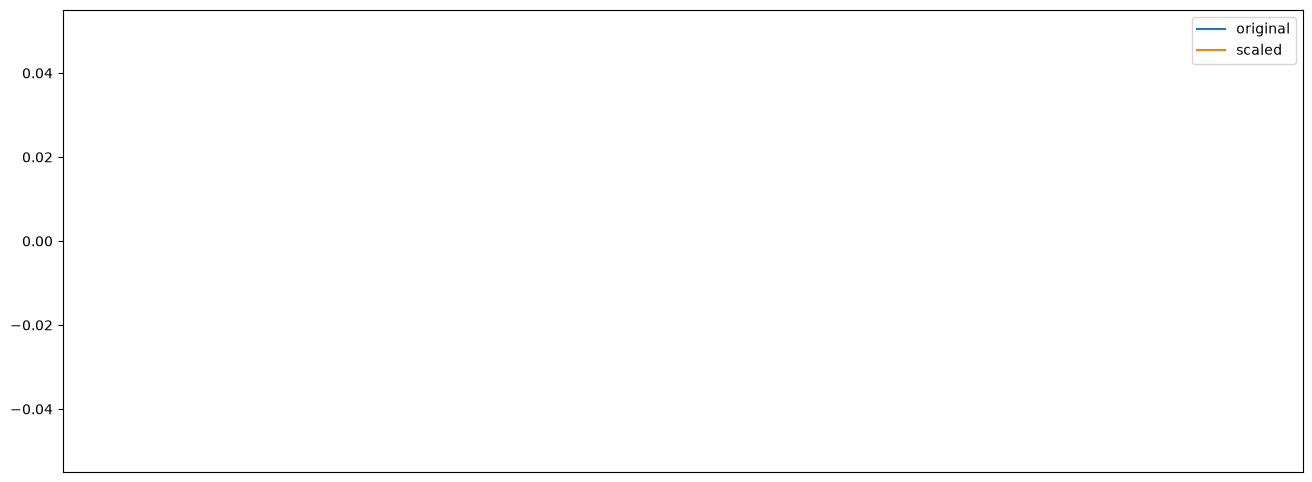

In [41]:
if is_plot:
    fig, axis = plt.subplots(1)
    fig.set_figwidth(16)
    fig.set_figheight(6)
    plt.plot(origin_tendon_length, label = "original")
    plt.plot(scaled_tendon_length, label = "scaled")
    plt.xticks(np.arange(len(tendon_names)), tendon_names, rotation = 90)
    plt.legend()

# Save result

In [42]:
params_to_save = {
    "body_pos": jax.device_get(scaled_model.body_pos),
    "site_pos": jax.device_get(scaled_model.site_pos),
    "geom_pos": jax.device_get(scaled_model.geom_pos),
    "geom_size": jax.device_get(scaled_model.geom_size),
    "tendon_length0" : jax.device_get(scaled_model.tendon_length0),
}

np.savez(save_path, **params_to_save)
print(f"save: {save_path}")

save: /mnt/ext1/seojin/temp/scale/scaled_param.npz
